<a href="https://colab.research.google.com/github/tankidunki/Image_Denoising_Autoencoder/blob/main/Image_Denoising_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Practical 5 Autoencoder image cleaning
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

In [ ]:
#load MNIST Dataset
(x_train, _), (x_test, _) = mnist.load_data()

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
noise_factor = 0.3
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
    )
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
    )


In [ ]:
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [ ]:
input_img = Input(shape=(28, 28))

x = Flatten()(input_img)

x = Dense(128, activation="relu")(x)

latent = Dense(64, activation="relu")(x)

In [ ]:
x = Dense(128, activation="relu")(latent)

x = Dense(784, activation="sigmoid")(x)

output = Reshape((28, 28))(x)

In [ ]:
autoencoder = Model(input_img, output)

In [ ]:
autoencoder.compile(
    optimizer='adam',
    loss='mse')

In [ ]:
autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0585 - val_loss: 0.0326
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0271 - val_loss: 0.0230
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0214 - val_loss: 0.0192
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0183 - val_loss: 0.0170
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0165 - val_loss: 0.0155
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0154 - val_loss: 0.0146
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0145 - val_loss: 0.0140
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0138 - val_loss: 0.0132
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0132 - val_loss: 0.0128
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0128 - val_loss: 0.0123


In [ ]:
decoded = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


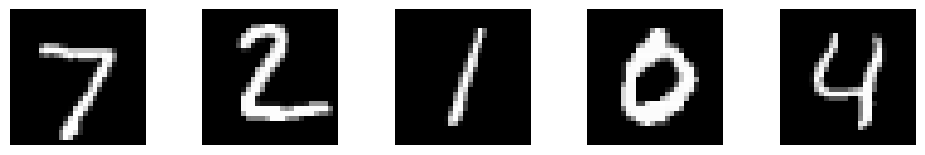

In [ ]:
n = 5

plt.figure(figsize=(12,6))

for i in range(n):

  plt.subplot(3, n, i + 1)
  plt.imshow(x_test[i], cmap='gray')
  plt.axis('off')
  if i == 0:
    plt.ylabel("Original")

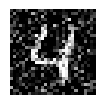

In [ ]:
plt.subplot(3,n,i+1+n)

plt.imshow(x_test_noisy[i], cmap='gray')
plt.axis('off')

if i==0:
  plt.ylabel("Noisy")

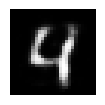

In [ ]:
plt.subplot(3,n,i+1+2*n)
plt.imshow(decoded[i], cmap='gray')
plt.axis('off')

if i==0:
  plt.ylabel("Reconstructed")

plt.show()